# This notebook will include a complete benchmarking and statistical comparison to the observed flow of the 2022 Mauna Loa eruption.

In [84]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import subprocess
import os
import utm
import xarray as xr
import rasterio as rio
from pyproj import Transformer
import sys
import glob
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor

### First, let's take a look at the footprint from Sentinel-1 InSAR. 

Before anything else, let's log in to access the satellite data.

In [2]:
# Generates authentication token
# Asks for your Earthdata username and password for first time, if netrc does not exists.

from platform import system
from netrc import netrc
from shapely.geometry import box
from shapely.geometry import Point
import datetime as dt
import asf_search as asf
import geopandas as gpd
import pandas as pd

## Avoid lots of these warnings printing to notebook from asf_search
import warnings
warnings.filterwarnings('ignore')

urs = 'urs.earthdata.nasa.gov'    # Earthdata URL endpoint for authentication
prompts = ['Enter NASA Earthdata Login Username: ',
           'Enter NASA Earthdata Login Password: ']

# Determine the OS (Windows machines usually use an '_netrc' file)
netrc_name = "_netrc" if system()=="Windows" else ".netrc"

# Determine if netrc file exists, and if so, if it includes NASA Earthdata Login Credentials
try:
    netrcDir = os.path.expanduser(f"~/{netrc_name}")
    netrc(netrcDir).authenticators(urs)[0]

# Below, create a netrc file and prompt user for NASA Earthdata Login Username and Password
except FileNotFoundError:
    homeDir = os.path.expanduser("~")
    Popen('touch {0}{2} | echo machine {1} >> {0}{2}'.format(homeDir + os.sep, urs, netrc_name), shell=True)
    Popen('echo login {} >> {}{}'.format(getpass(prompt=prompts[0]), homeDir + os.sep, netrc_name), shell=True)
    Popen('echo \'password {} \'>> {}{}'.format(getpass(prompt=prompts[1]), homeDir + os.sep, netrc_name), shell=True)
    # Set restrictive permissions
    Popen('chmod 0600 {0}{1}'.format(homeDir + os.sep, netrc_name), shell=True)

    # Determine OS and edit netrc file if it exists but is not set up for NASA Earthdata Login
except TypeError:
    homeDir = os.path.expanduser("~")
    Popen('echo machine {1} >> {0}{2}'.format(homeDir + os.sep, urs, netrc_name), shell=True)
    Popen('echo login {} >> {}{}'.format(getpass(prompt=prompts[0]), homeDir + os.sep, netrc_name), shell=True)
    Popen('echo \'password {} \'>> {}{}'.format(getpass(prompt=prompts[1]), homeDir + os.sep, netrc_name), shell=True)

## Enter user-defined parameters
aoi = box(-155.6189, 19.3253, -155.4801, 19.6855)     # (W, S, E, N)
orbitPass = "DESCENDING"
pathNumber = 87
referenceDate = dt.datetime.fromisoformat('2022-11-22 00:00:00')         #'YYYY-MM-DD HH:MM:SS'
secondaryDate = dt.datetime.fromisoformat('2022-12-05 23:59:59')         #'YYYY-MM-DD HH:MM:SS'
savedir = './MaunaLoa_2022/'

### Using the `asf_search` package, we can query and download OPERA CSLCs.

In [3]:
## Search for OPERA CSLC data in ASF DAAC
try:
    search_params = dict(
        intersectsWith= aoi,
        dataset='OPERA-S1',
        processingLevel='CSLC',
        flightDirection = orbitPass,
        start=referenceDate,
        end=secondaryDate)

    ## Return results
    results = asf.search(**search_params)
    print(f"Length of Results: {len(results)}")

except TypeError:
    search_params = dict(
        intersectsWith= aoi.wkt,
        dataset='OPERA-S1',
        processingLevel='CSLC',
        flightDirection = orbitPass,
        start=referenceDate,
        end=secondaryDate)

    ## Return results
    results = asf.search(**search_params)
    print(f"Length of Results: {len(results)}")

Length of Results: 6


### Now that some granules have been found, we can take a look at them, both in table form and on the map!

In [4]:
## Save the results in a geopandas dataframe
gf = gpd.GeoDataFrame.from_features(results.geojson(), crs='EPSG:4326')

## Filter data based on specified track number
gf = gf[gf.pathNumber==pathNumber]
gf = gf[gf.pgeVersion=="2.1.1"]

cslc_df = gf[['operaBurstID', 'fileID', 'startTime', 'stopTime', 'url', 'geometry', 'pgeVersion']]
cslc_df['startTime'] = pd.to_datetime(cslc_df.startTime).dt.date
cslc_df['stopTime'] = pd.to_datetime(cslc_df.stopTime).dt.date
cslc_df = cslc_df.drop_duplicates(subset=['operaBurstID', 'startTime'], ignore_index=True)
cslc_df

,operaBurstID,fileID,startTime,stopTime,url,geometry,pgeVersion
0,T087_185683_IW2,OPERA_L2_CSLC-S1_T087-185683-IW2_20221204T1616...,2022-12-04,2022-12-04,https://datapool.asf.alaska.edu/CSLC/OPERA-S1/...,"POLYGON ((-155.34903 19.41464, -156.1782 19.56...",2.1.1
1,T087_185682_IW2,OPERA_L2_CSLC-S1_T087-185682-IW2_20221204T1616...,2022-12-04,2022-12-04,https://datapool.asf.alaska.edu/CSLC/OPERA-S1/...,"POLYGON ((-155.31899 19.58157, -156.14521 19.7...",2.1.1
2,T087_185681_IW2,OPERA_L2_CSLC-S1_T087-185681-IW2_20221204T1616...,2022-12-04,2022-12-04,https://datapool.asf.alaska.edu/CSLC/OPERA-S1/...,"POLYGON ((-155.28443 19.74819, -156.11213 19.8...",2.1.1
3,T087_185683_IW2,OPERA_L2_CSLC-S1_T087-185683-IW2_20221122T1616...,2022-11-22,2022-11-22,https://datapool.asf.alaska.edu/CSLC/OPERA-S1/...,"POLYGON ((-155.35322 19.41478, -156.17956 19.5...",2.1.1
4,T087_185682_IW2,OPERA_L2_CSLC-S1_T087-185682-IW2_20221122T1616...,2022-11-22,2022-11-22,https://datapool.asf.alaska.edu/CSLC/OPERA-S1/...,"POLYGON ((-155.32022 19.58181, -156.14645 19.7...",2.1.1
5,T087_185681_IW2,OPERA_L2_CSLC-S1_T087-185681-IW2_20221122T1616...,2022-11-22,2022-11-22,https://datapool.asf.alaska.edu/CSLC/OPERA-S1/...,"POLYGON ((-155.28572 19.74818, -156.11342 19.8...",2.1.1


In [5]:
cslc_df[['operaBurstID', 'geometry']].explore(zoom=9, tiles="CartoDB positron")

### The next cells download the files, as well as implement a number of helper functions.

Some of these include colorizing and unwrapping the interferogram layers, and writes the passes to a raster file. Click on the second cell to open it!

In [6]:
## Download the relevant OPERA CSLCs to a temporary "cslc" folder 
os.makedirs(f'{savedir}/cslc', exist_ok='True')
asf.download_urls(urls=cslc_df.url, path=f'{savedir}/cslc', processes=10)

cslc_df = cslc_df.sort_values(by=["startTime", "operaBurstID"], ignore_index=True)

In [7]:
def read_cslc(h5file):
    grid_path = f'data'
    metadata_path = f'metadata'
    burstmetadata_path = f'metadata/processing_information/input_burst_metadata'
    id_path = f'identification'

    with h5py.File(h5file,'r') as h5:
        # print(f'Opening: {h5file}')  
        cslc = h5[f'{grid_path}/VV'][:]
        xcoor = h5[f'{grid_path}/x_coordinates'][:]
        ycoor = h5[f'{grid_path}/y_coordinates'][:]
        dx = h5[f'{grid_path}/x_spacing'][()].astype(int)
        dy = h5[f'{grid_path}/y_spacing'][()].astype(int)
        epsg = h5[f'{grid_path}/projection'][()].astype(int)
        sensing_start = h5[f'{burstmetadata_path}/sensing_start'][()].astype(str)
        sensing_stop = h5[f'{burstmetadata_path}/sensing_stop'][()].astype(str)
        dims = h5[f'{burstmetadata_path}/shape'][:]
        bounding_polygon = h5[f'{id_path}/bounding_polygon'][()].astype(str) 
        orbit_direction = h5[f'{id_path}/orbit_pass_direction'][()].astype(str)
        center_lon, center_lat = h5[f'{burstmetadata_path}/center']
        wavelength = h5[f'{burstmetadata_path}/wavelength'][()].astype(str)
        
    return cslc,xcoor, ycoor, dx, dy, epsg, sensing_start, sensing_stop, dims, bounding_polygon, orbit_direction, center_lon, center_lat, wavelength

def colorize(array=[], cmap='RdBu', cmin=[], cmax=[]) -> np.ndarray:
    """
    Function to assign colors to an array based on a normalized colormap.

    Parameters:
    -----------
    array : numpy array
        Input array.
    cmap : str
        Colormap to be used.
    cmin : float
        Minimum value of the array.
    cmax : float
        Maximum value of the array. 

    Returns
    -------
    cm : numpy array
        Colorized array.

    """
    normed_data = (array - cmin) / (cmax - cmin)    
    cm = plt.cm.get_cmap(cmap)
    return cm(normed_data) 

def moving_window_mean(image, size) -> np.ndarray:
    """Calculate the mean of a moving window of size `size`.

    Parameters
    ----------
    image : ndarray
        input image
    size : int or tuple of int
        Window size. If a single int, the window is square.
        If a tuple of (row_size, col_size), the window can be rectangular.

    Returns
    -------
    ndarray
        image the same size as `image`, where each pixel is the mean
        of the corresponding window.
    """
    if isinstance(size, int):
        size = (size, size)
    if len(size) != 2:
        raise ValueError("size must be a single int or a tuple of 2 ints")
    if size[0] % 2 == 0 or size[1] % 2 == 0:
        size = tuple(map(sum, zip(size, (1,1))))

    row_size, col_size = size
    row_pad = row_size // 2
    col_pad = col_size // 2

    # Pad the image with zeros
    image_padded = np.pad(
        image, ((row_pad + 1, row_pad), (col_pad + 1, col_pad)), mode="constant"
    )

    # Calculate the cumulative sum of the image
    integral_img = np.cumsum(np.cumsum(image_padded, axis=0), axis=1)
    if not np.iscomplexobj(integral_img):
        integral_img = integral_img.astype(float)

    # Calculate the mean of the moving window
    # Uses the algorithm from https://en.wikipedia.org/wiki/Summed-area_table
    window_mean = (
        integral_img[row_size:, col_size:]
        - integral_img[:-row_size, col_size:]
        - integral_img[row_size:, :-col_size]
        + integral_img[:-row_size, :-col_size]
    )
    window_mean /= row_size * col_size
    
    return window_mean

def calc_ifg_coh(reference, secondary) -> tuple:
    """
    Function to calculate the interferogram, coherence, and amplitude from the reference and secondary images.
    
    Parameters:
    -----------
    reference : numpy array
        Reference image.
    secondary : numpy array
        Secondary image.

    Returns
    -------
    ifg : numpy array
        Interferogram.
    coh : numpy array
        Interferometric correlation or coherence
    amp : numpy array 
        Amplitude of the interferogram
    """

    ifg_raw = reference * np.conjugate(secondary)
    amp = np.sqrt((reference * np.conjugate(reference)) * (secondary * np.conjugate(secondary)))
    ifg_cpx = np.exp(1j * np.nan_to_num(np.angle(ifg_raw)))
    ifg_smooth = moving_window_mean(ifg_cpx,(2,4))
    ifg = np.nan_to_num(np.angle(ifg_smooth))
    nan_mask = np.isnan(ifg_raw)
    ifg[nan_mask] = np.nan

    norm_ifg_cpx = np.exp(1j * np.nan_to_num(np.angle(ifg_raw/amp)))
    coh = np.clip(np.abs(moving_window_mean(norm_ifg_cpx, 5)), 0, 1)
    zero_mask = ifg_raw == 0
    coh[nan_mask] = np.nan
    coh[zero_mask] = 0

    return ifg, coh, amp

def rasterWrite(outtif,arr,transform,epsg,dtype='float32'):
    """
    Function to write a numpy array to a GeoTIFF file.
    
    Parameters:
    -----------
    outtif : str
        Output GeoTIFF filename.
    arr : numpy array
        Input array.
    transform : rasterio.transform
        Affine transformation.
    epsg : int
        EPSG code.
    dtype : str
        Data type of the output array. Default is 'float32'.
    """
    
    new_dataset = rasterio.open(outtif, 'w', driver='GTiff',
                            height = arr.shape[0], width = arr.shape[1],
                            count=1, dtype=dtype,
                            crs=CRS.from_epsg(epsg),
                            transform=transform,nodata=np.nan)
    new_dataset.write(arr, 1)
    new_dataset.close() 

### Now, we can properly process and plot each CSLC file.

2022-11-22
Opening: ./MaunaLoa_2022//cslc/OPERA_L2_CSLC-S1_T087-185681-IW2_20221122T161647Z_20240504T081640Z_S1A_VV_v1.1.h5
2022-11-22
Opening: ./MaunaLoa_2022//cslc/OPERA_L2_CSLC-S1_T087-185682-IW2_20221122T161650Z_20240504T081640Z_S1A_VV_v1.1.h5
2022-11-22
Opening: ./MaunaLoa_2022//cslc/OPERA_L2_CSLC-S1_T087-185683-IW2_20221122T161653Z_20240504T081640Z_S1A_VV_v1.1.h5
2022-12-04
Opening: ./MaunaLoa_2022//cslc/OPERA_L2_CSLC-S1_T087-185681-IW2_20221204T161646Z_20240504T113337Z_S1A_VV_v1.1.h5
2022-12-04
Opening: ./MaunaLoa_2022//cslc/OPERA_L2_CSLC-S1_T087-185682-IW2_20221204T161649Z_20240504T113337Z_S1A_VV_v1.1.h5
2022-12-04
Opening: ./MaunaLoa_2022//cslc/OPERA_L2_CSLC-S1_T087-185683-IW2_20221204T161652Z_20240504T113337Z_S1A_VV_v1.1.h5


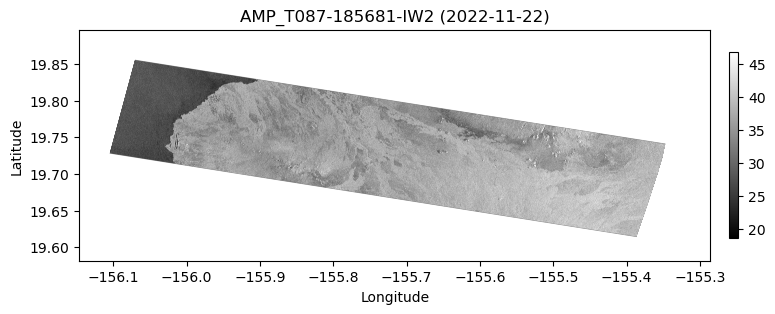

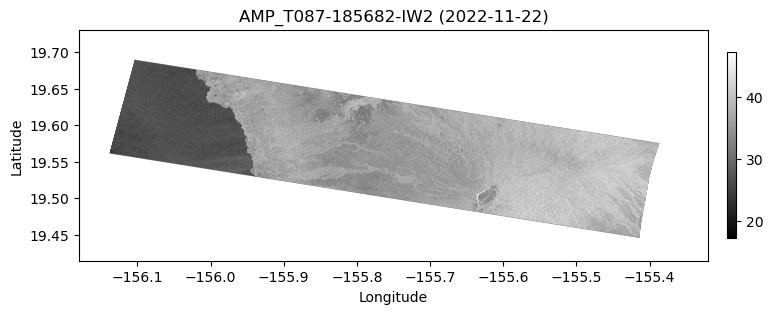

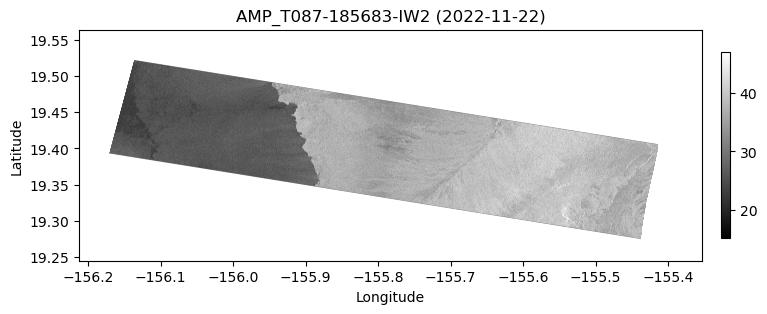

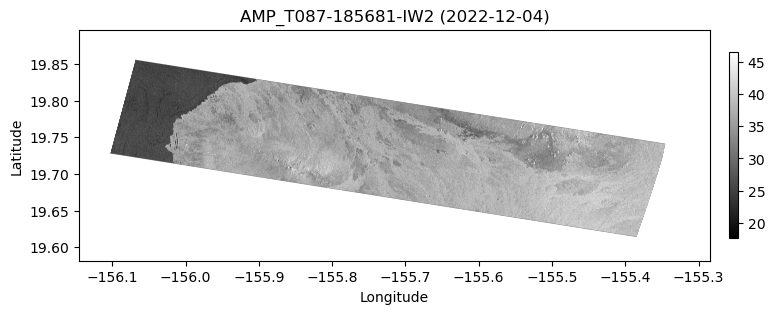

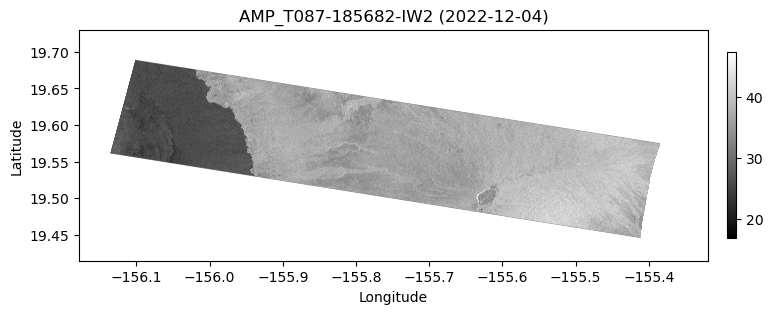

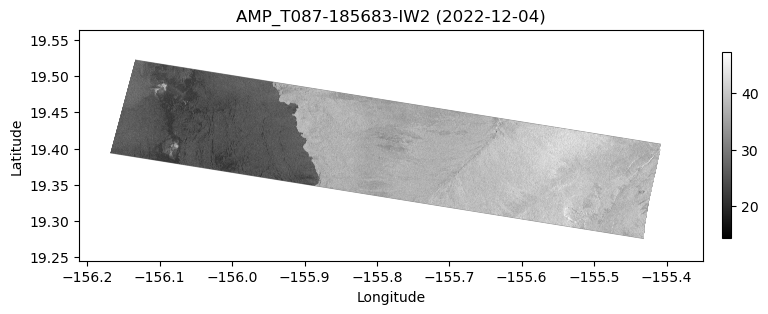

In [8]:
import h5py
import shapely.wkt as wkt

cslc_stack = []; cslc_dates = []; bbox_stack = []; xcoor_stack = []; ycoor_stack = [];
for fileID, start_date in zip(cslc_df.fileID, cslc_df.startTime):
    print(pd.to_datetime(start_date).date())
    cslc, xcoor, ycoor, dx, dy, epsg, sensing_start, sensing_stop, dims, bounding_polygon, orbit_direction, center_lon, center_lat, wavelength = read_cslc(f"{savedir}/cslc/{fileID}.h5")
    cslc_stack.append(cslc)
    cslc_dates.append(pd.to_datetime(sensing_start).date())
    
    # Plot
    cslc_poly = wkt.loads(bounding_polygon)
    bbox = [cslc_poly.bounds[0], cslc_poly.bounds[2], cslc_poly.bounds[1], cslc_poly.bounds[3]]
    scale_factor = 1.0; exp_factor= 0.2
    fig, ax = plt.subplots(figsize=(12, 3))
    cax=ax.imshow(20*np.log10(np.abs(cslc)), cmap='gray',interpolation=None, origin='upper', extent=bbox, vmin=np.nanpercentile(20*np.log10(np.abs(cslc)),2), vmax=np.nanpercentile(20*np.log10(np.abs(cslc)),98))
    cbar = fig.colorbar(cax,orientation='vertical',fraction=0.01,pad=0.02)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'AMP_{fileID.split("_")[3]} ({pd.to_datetime(start_date).date()})',fontsize=12)

    #Save metadata stack
    bbox_stack.append(bbox)
    xcoor_stack.append(xcoor)
    ycoor_stack.append(ycoor)

### In the penultimate part of this section, we can compute for the coherence and save the granules as individual GeoTiffs.

In [9]:
## Get the dates, burstIDs, and number of bursts 
cslc_dates = cslc_df[["startTime"]]
burstID = cslc_df.operaBurstID.drop_duplicates(ignore_index=True)
n_unique_burstID = len(burstID)

In [10]:
from rasterio.transform import from_origin
from rasterio import merge
from rasterio.crs import CRS
import rasterio
## For each date-pair, calculate the ifg, coh. Save the results as GeoTiffs.
for i in range(0,n_unique_burstID):
    ref_date = cslc_dates.iloc[i].values[0]
    sec_date = cslc_dates.iloc[i+n_unique_burstID].values[0]
    print(f"Reference: {ref_date}  Secondary: {sec_date}")

    # Calculate ifg, coh, amp
    ifg, coh, amp = calc_ifg_coh(cslc_stack[i], cslc_stack[i+n_unique_burstID])
    
    # Save each interferogram as GeoTiff
    os.makedirs(f'{savedir}/tifs', exist_ok='True')
    transform = from_origin(xcoor_stack[i][0],ycoor_stack[i][0],dx,np.abs(dy))
    rasterWrite(f'{savedir}/tifs/coh_{burstID.iloc[i]}_{ref_date.strftime("%Y%m%d")}-{sec_date.strftime("%Y%m%d")}.tif',coh,transform,epsg,dtype=rasterio.float32)

Reference: 2022-11-22  Secondary: 2022-12-04
Reference: 2022-11-22  Secondary: 2022-12-04
Reference: 2022-11-22  Secondary: 2022-12-04


### Finally, we can merge the coherence and save it as a unified GeoTiff.

In [11]:
def custom_merge(old_data, new_data, old_nodata, new_nodata, **kwargs):    
    mask = np.logical_and(~old_nodata, ~new_nodata)
    old_data[mask] = new_data[mask]
    mask = np.logical_and(old_nodata, ~new_nodata)
    old_data[mask] = new_data[mask]

In [12]:
# Merge burst-wise coherence
coh_files = [(f'{savedir}/tifs/coh_{id}_{ref_date.strftime("%Y%m%d")}-{sec_date.strftime("%Y%m%d")}.tif') for id in burstID]
coh_files_to_mosaic = []

for f in coh_files:
    src = rasterio.open(f)
    coh_files_to_mosaic.append(src)

# Write merged coherence to GeoTiff
dest, output_transform=merge.merge(coh_files_to_mosaic, method=custom_merge)
with rasterio.open(coh_files[0]) as src:
        out_meta = src.meta.copy() 
out_meta.update({"driver": "GTiff",
                 "height": dest.shape[1],
                 "width": dest.shape[2],
                 "transform": output_transform})
with rasterio.open(f"{savedir}/tifs/merged_coh.tif", "w", **out_meta) as dest1:
        dest1.write(dest)
        dest1.close()

In [3]:
# Read the merged coherence file
savedir="MaunaLoa_2022"
src = rxr.open_rasterio(f"{savedir}/tifs/merged_coh.tif")
merged_coh = src.rio.reproject("EPSG:4326")[0]             # Folium maps are in EPSG:4326
minlon,minlat,maxlon,maxlat = merged_coh.rio.bounds()

### Now, let's take a look at the final product.

We ask the user to interactively select a point on the flow footprint. This serves two purposes:

1. Provide a starting point for the simulations of the flows.
2. Set a seed point for the extraction of the flow outline.

In [85]:
import leafmap
m = leafmap.Map()
m.add_raster(f"{savedir}/tifs/merged_coh.tif", cmap='hot', layer_name="DEM")
m

Map(center=[19.5684945, -155.73951], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

### Now, we trim the coherence to reduce processing time and increase overall effiency.

In [86]:
coords = m.user_roi["geometry"]['coordinates']
tform = Transformer.from_crs("EPSG:4326", src.rio.crs.to_string())
coords_utm = tform.transform(coords[1], coords[0])
cropped_src = src[0, 1000:-1000,10000:-1000]
cropped_src.rio.to_raster("coherence_trimmed.tif")
a = src.sel(x=coords_utm[0], y=coords_utm[1], method="nearest")
x_ind, y_ind = np.where(cropped_src.x.values == a.x.values), np.where(cropped_src.y.values == a.y.values)
x_ind, y_ind = x_ind[0][0], y_ind[0][0]

### Below, we segment and extract the footprint. The segment is displayed at completion, with a visualization of the process in the following cell.

Min value: 0.0
Max value: 1.0
Mean value: 0.6183556914329529
Valid pixels: 54821196 out of 73547440
Using threshold for potential regions: 0.33
Using seed point at coordinates: (4062, 4860)


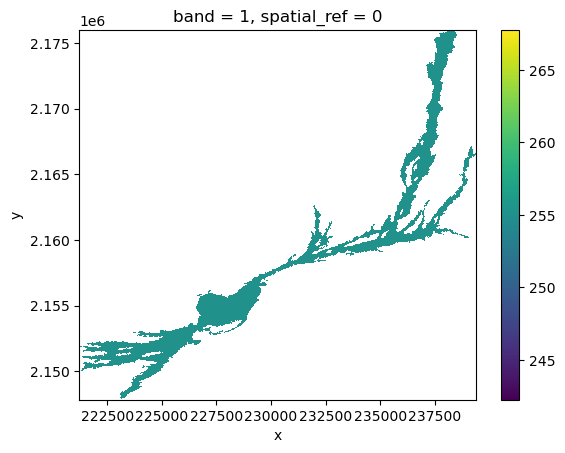

In [89]:
import numpy as np
import rasterio
from skimage import exposure, filters, morphology, segmentation, measure
import matplotlib.pyplot as plt
from scipy import ndimage

# Open the GeoTIFF
with rasterio.open('coherence_trimmed.tif') as src:
    image = src.read(1)
    transform = src.transform
    meta = src.meta
    
    # Handle nodata and NaN values more carefully
    if src.nodata is not None:
        valid_mask = image != src.nodata
    else:
        valid_mask = np.ones_like(image, dtype=bool)
    
    # Additionally filter out NaN values
    valid_mask = valid_mask & ~np.isnan(image)
    
    # Check if we have valid data
    if not np.any(valid_mask):
        print("No valid data found in the image!")
        exit()
    
    # Create a working copy with NaN/nodata replaced
    working_img = image.copy()
    if not np.all(valid_mask):
        valid_data = working_img[valid_mask]
        if len(valid_data) > 0:
            median_val = np.median(valid_data)
            working_img[~valid_mask] = median_val
        else:
            print("No valid data to compute median!")
            exit()

# Print some statistics to debug
print(f"Min value: {np.min(working_img[valid_mask])}")
print(f"Max value: {np.max(working_img[valid_mask])}")
print(f"Mean value: {np.mean(working_img[valid_mask])}")
print(f"Valid pixels: {np.sum(valid_mask)} out of {valid_mask.size}")

# Apply contrast stretching to make the dark features more prominent
p2, p98 = np.percentile(working_img[valid_mask], (2, 98))
stretched = exposure.rescale_intensity(working_img, in_range=(p2, p98))

# Create a binary mask based on a good threshold for potential lava regions
# This will be our search space for region growing
min_val = np.min(working_img[valid_mask])
max_val = np.max(working_img[valid_mask])
range_val = max_val - min_val

# Let's use a threshold that captures dark regions (potential lava)
# You might need to adjust this based on your specific image
threshold = .33  # Using a low threshold to capture dark features
print(f"Using threshold for potential regions: {threshold}")

# Create binary mask of potential lava regions
binary_mask = np.zeros_like(working_img, dtype=bool)
binary_mask[valid_mask] = working_img[valid_mask] < threshold

# Clean up the binary mask 
binary_mask = morphology.remove_small_objects(binary_mask, min_size=200)
binary_mask = morphology.binary_closing(binary_mask, morphology.disk(3))
binary_mask = morphology.remove_small_holes(binary_mask, area_threshold=300)

# Find largest connected components which might be candidates for the lava flow
labeled_mask, num_features = ndimage.label(binary_mask)
component_sizes = np.bincount(labeled_mask.ravel())
component_sizes[0] = 0  # Ignore background

# seed_point = (5500,4000)
seed_point = (y_ind, x_ind)

print(f"Using seed point at coordinates: {seed_point}")

# Create a mask for seed point
seed_mask = np.zeros_like(working_img, dtype=bool)
seed_mask[seed_point] = True

# Use region growing from the seed point within the binary mask
# The approach depends on the intensity consistency of your lava flow
# Option 1: Use flood filling within the binary mask
lava_flow_mask = np.zeros_like(binary_mask)
# Make sure seed point is within a valid region
if binary_mask[seed_point]:
    # Use flood fill to grow the region from the seed
    lava_flow_mask = segmentation.flood(binary_mask, seed_point)
else:
    print("Warning: Seed point is not within a valid region!")
    # In this case, we'll use the component containing the seed point
    component_at_seed = labeled_mask[seed_point]
    if component_at_seed > 0:
        lava_flow_mask = labeled_mask == component_at_seed
    else:
        # Find nearest valid component
        distances = ndimage.distance_transform_edt(~binary_mask)
        nearest_valid_point_idx = np.argmin(distances)
        nearest_valid_point = np.unravel_index(nearest_valid_point_idx, distances.shape)
        component_at_nearest = labeled_mask[nearest_valid_point]
        if component_at_nearest > 0:
            lava_flow_mask = labeled_mask == component_at_nearest
        else:
            print("Could not find a valid region near the seed point.")
            lava_flow_mask = binary_mask  # Fallback to original mask

# Clean up the result
lava_flow_mask = morphology.binary_closing(lava_flow_mask, morphology.disk(3))
lava_flow_mask = morphology.remove_small_holes(lava_flow_mask, area_threshold=500)

# Save the segmented lava flow mask
lava_flow_int = lava_flow_mask.astype(np.uint8) * 255
with rasterio.open('lava_flow_mask.tif', 'w',
                  driver='GTiff',
                  height=lava_flow_mask.shape[0],
                  width=lava_flow_mask.shape[1],
                  count=1,
                  dtype=np.uint8,
                  crs=meta['crs'],
                  transform=transform,
                  nodata=0) as dst:
    dst.write(lava_flow_int, 1)
r = rxr.open_rasterio("lava_flow_mask.tif", masked=True)
r = r.dropna(dim='x',how='all')
r = r.dropna(dim='y',how='all')
r.plot()
r.rio.to_raster("lava_flow_mask_cropped.tif")

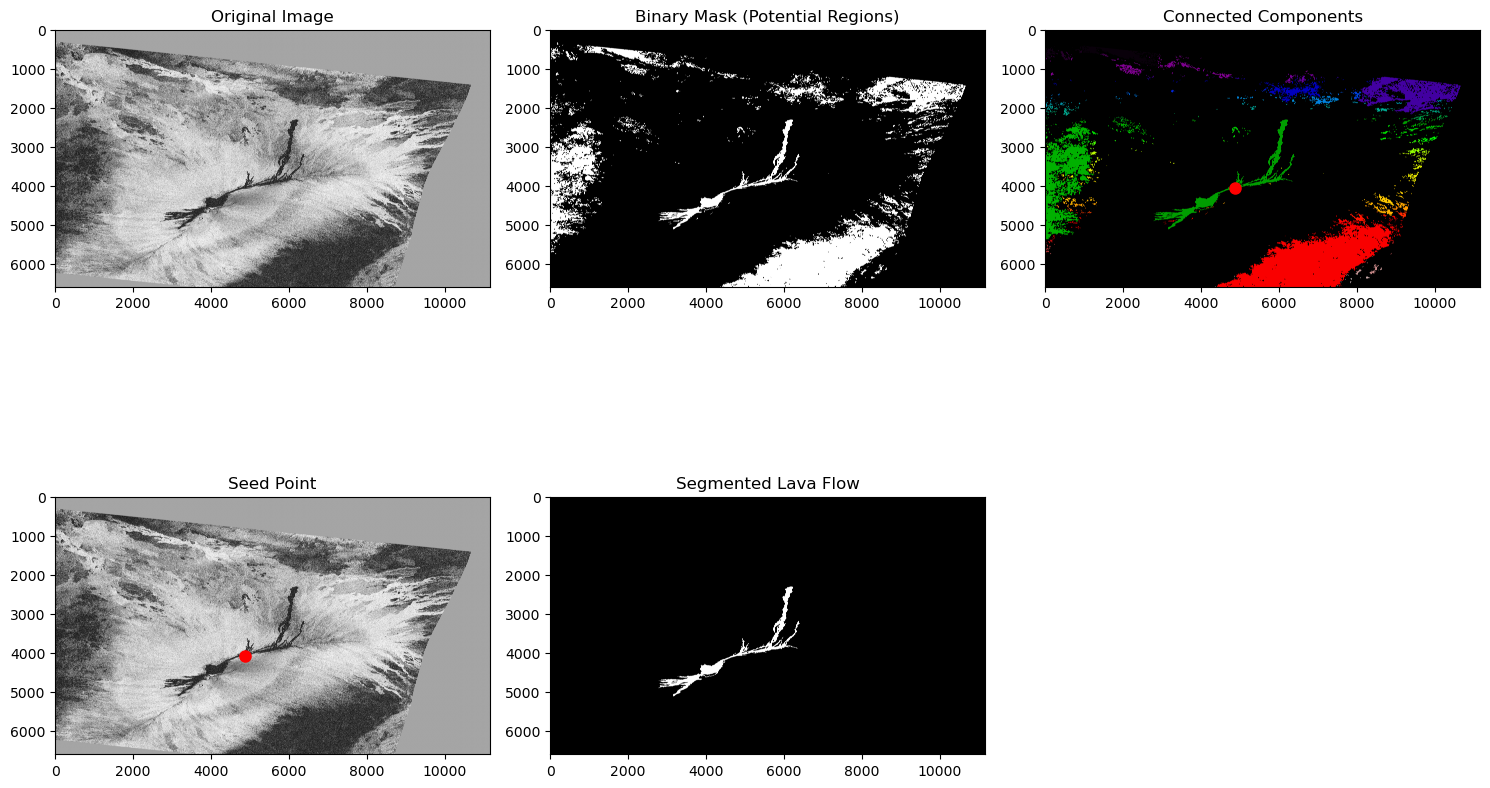

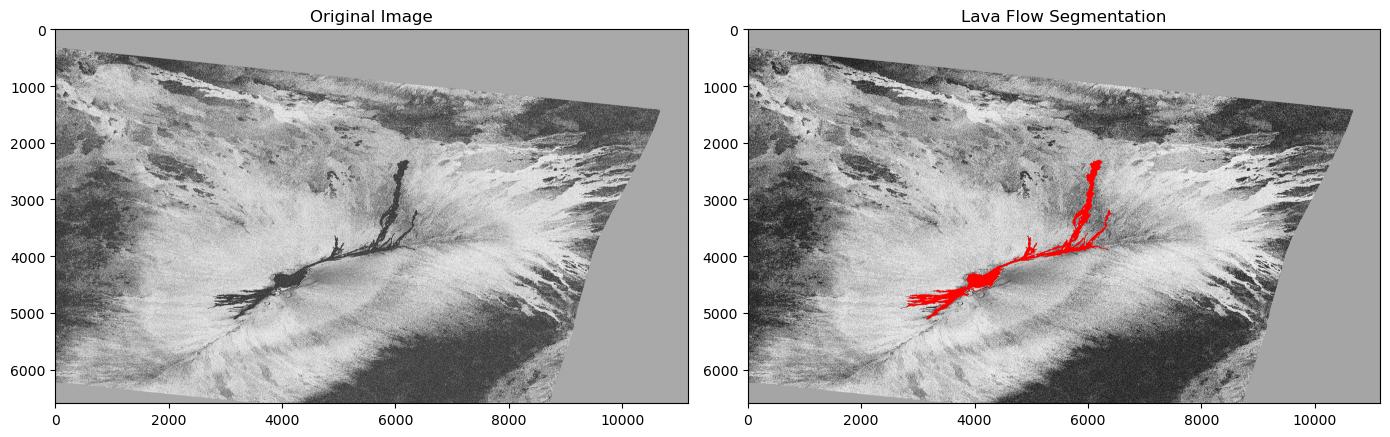

In [90]:
# Visualization of intermediary results
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(stretched, cmap='gray')

plt.subplot(2, 3, 2)
plt.title("Binary Mask (Potential Regions)")
plt.imshow(binary_mask, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("Connected Components")
plt.imshow(labeled_mask, cmap='nipy_spectral')
plt.plot(seed_point[1], seed_point[0], 'ro', markersize=8)  # Mark seed point

plt.subplot(2, 3, 4)
plt.title("Seed Point")
plt.imshow(stretched, cmap='gray')
plt.plot(seed_point[1], seed_point[0], 'ro', markersize=8)

plt.subplot(2, 3, 5)
plt.title("Segmented Lava Flow")
plt.imshow(lava_flow_mask, cmap='gray')

plt.tight_layout()
plt.show()

# Final visualization
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(working_img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Lava Flow Segmentation")
# Create color overlay for segmentation
seg_overlay = np.zeros((working_img.shape[0], working_img.shape[1], 3))
seg_overlay[:,:,0] = stretched / np.max(stretched)
seg_overlay[:,:,1] = stretched / np.max(stretched)
seg_overlay[:,:,2] = stretched / np.max(stretched)
seg_overlay[lava_flow_mask, 0] = 1.0  # Red channel
seg_overlay[lava_flow_mask, 1] = 0.0  # Green channel
seg_overlay[lava_flow_mask, 2] = 0.0  # Blue channel
plt.imshow(seg_overlay)

plt.tight_layout()
plt.show()

### Now begins the benchmark. 

Most of the setup is already done for you, but a few values are left to input.

In [ ]:
# Total volume in m^3 from eruption
volume = 2.5e8

# Name to reference files
name = "MaunaLoa"

# IMEX and Lava2d are depth-averaged time-dependent models, and thus require an approximate run time.
# Below, we assign a reasonable yet arbitrary time (3 hour) for the flow to run (in seconds)
# Please change it at your leisure
run_time = 10800

# Please enter 1, 2, or 4 (original resolution, half, quarter respectively)
downscale = 2

### The next two cells format and set up for a clean execution.

In [ ]:
dem = "hawaii.tif"

vent_latitude = coords[1]
vent_longitude = coords[0]

raster = rxr.open_rasterio(dem)
raster = raster.sel({"band": 1})
output_num = str(int(run_time/100))
out = output_num.zfill(4)

filename, file_extension = os.path.splitext(dem)
file_name = os.path.basename(dem)
file_name = os.path.splitext(file_name)[0]
type_flag = 0 #0 is ascii, 1 is tiff
if file_extension in [".geotiff", ".tiff", ".tif"]:
    type_flag = 1
    asc_name = "".join((name,".asc"))
    victor.tiff_to_utm_ascii(dem,asc_name)
elif file_extension in [".asc", ".ascii"]:
    type_flag = 0
    tiff_name = "".join((file_name, ".tiff"))
    raster.rio.to_raster(tiff_name)

In [ ]:
rstr = rio.open(asc_name)
bounds = rstr.bounds
crs = rstr.crs
res = rstr.res
transformer = Transformer.from_crs(crs.to_string(), "EPSG:4326")
transformer2 = Transformer.from_crs("EPSG:4326", crs.to_string())
converted = transformer2.transform(vent_latitude,vent_longitude)

vent_easting = converted[0]
vent_northing = converted[1]

xll, yll = int(bounds.left), int(bounds.bottom)
coordinates = np.array([int(vent_easting),int(vent_northing)])
r = rio.open(dem)
array = rxr.open_rasterio(asc_name)

### Before we jump into the computation, we confirm the location of the vent we want to use.

In [ ]:
victor.plot_dem(dem, np.array([vent_longitude,vent_latitude]))

### Now, we can run everything. Press run on every cell until the next text box.

Keep in mind, the time dependent models can take a long time, so sit back and relax, though keep an eye out for your results.

In [ ]:
os.chdir("/home/jovyan/Lava Benchmark/Molasses")
f = open("custom_molasses.conf","r+")
conf = f.readlines()
conf[2] = "MIN_RESIDUAL = .1\n"
conf[3] = "MAX_RESIDUAL = 2\n"
conf[4] = f"""MIN_TOTAL_VOLUME = {str(volume)}\n"""
conf[5] = f"""MAX_TOTAL_VOLUME = {str(volume)}\n"""
conf[6] = f"""MIN_PULSE_VOLUME = {float(volume)/1000}\n"""
conf[7] = f"""MAX_PULSE_VOLUME = {float(volume)/1000}\n"""
conf[10] = f"""DEM_FILE = {asc_name}\n"""
f.seek(0)
f.writelines(conf)
f.truncate()
f.close()

f=open("events.in","w")
f.write(f"""{vent_easting},{vent_northing}""")
f.close()

if not os.path.exists(f"../{dem}"):
    subprocess.run(f"""ln -s ../{dem} .""",shell=True)
subprocess.run("molasses custom_molasses.conf",shell=True, stderr=subprocess.DEVNULL)

victor.convert_molasses(f"molasses_{name}")
os.chdir("/home/jovyan/Lava Benchmark")

In [ ]:
victor.plot_flow("./Molasses/MaunaLoa.asc",f"./Molasses/molasses_{name}.asc")

In [ ]:
os.chdir("/home/jovyan/Lava Benchmark/mr_lava_loba")
g=open("input_data.py","r+")
inp = g.readlines()
inp[1] = f"""run_name = '{name}'\n"""
if type_flag == 1:
    inp[3] = f"""source = '{asc_name}'\n"""
else:
    inp[3] = f"""source = '{dem}'\n"""
inp[41] = f"""vent_flag = 0\n"""
inp[44] = f"""x_vent = [{int(vent_easting)}]\n"""
inp[45] = f"""y_vent = [{int(vent_northing)}]\n"""
inp[91] = f"""total_volume = {volume}\n"""
inp[96] = f"""fixed_dimension_flag = 1\n"""
g.seek(0)
g.writelines(inp)
g.truncate()
g.close()

if type_flag == 1:
    subprocess.run(f"""ln -s ../{asc_name} .""",shell=True)
else:
    subprocess.run(f"""ln -s ../{dem} .""",shell=True)
subprocess.run("python mr_lava_loba.py",shell=True)
os.chdir("/home/jovyan/Lava Benchmark/")

In [ ]:
mll_outputs = glob.glob(f'mr_lava_loba/{name}*thickness_masked*.asc')
mll_out = mll_outputs[-1]
victor.plot_flow(asc_name,mll_out)

In [ ]:
os.chdir("/home/jovyan/Lava Benchmark/IMEX_LavaFlow")
h=open("IMEX_LavaFlow.inp","r+")
inp = h.readlines()
inp[1] = f''' RUN_NAME="{name}"\n'''
inp[4] = f""" T_END=  {run_time},\n"""
inp[5] = f""" DT_OUTPUT=  1000,\n"""
inp[13] = f""" X0= {int(xll)+res[0]}     ,\n"""
inp[14] = f""" Y0= {int(yll)+res[0]}     ,\n"""
inp[15] = f""" COMP_CELLS_X=  {int(len(array.x)/downscale)-5},\n"""
inp[16] = f""" COMP_CELLS_Y=  {int(len(array.y)/downscale)-5},\n"""
inp[17] = f""" CELL_SIZE = {res[0]*downscale}D0 ,\n"""
inp[103] = f"""  X_SOURCE=  {int(vent_easting)}.0D0 ,\n"""
inp[104] = f"""  Y_SOURCE=  {int(vent_northing)}.0D0 ,\n"""
inp[105] = f"""  R_SOURCE=  {res[0]}D0     ,\n"""
inp[106] = f""" VEL_SOURCE= {float(volume)/(res[0]**2*np.pi*run_time)} \n"""
h.seek(0)
h.writelines(inp)
h.truncate()
h.close()

os.remove("topography_dem.asc")
if type_flag == 1:
    subprocess.run(f"""ln -s ../{asc_name} topography_dem.asc""",shell=True)
else:
    subprocess.run(f"""ln -s {dem} topography_dem.asc""",shell=True)
subprocess.run("./IMEX_LavaFlow",shell=True)
os.chdir("/home/jovyan/Lava Benchmark")

In [ ]:
os.chdir("/home/jovyan/Lava Benchmark/lava2d")
left, bottom, right, top = r.bounds
lower_left = transformer.transform(left, bottom)
top_right = transformer.transform(right, top)
src = transformer.transform(vent_easting, vent_northing)

l = open("input.py","r+")
inp = l.readlines()

if type_flag == 0:
    inp[4] = f"""    path_to_dem_file    = ('/home/jovyan/shared-readwrite/DEMs/MaunaLoa.tif'),\n"""
else:
    inp[4] = f"""    path_to_dem_file    = ('/home/jovyan/shared-readwrite/DEMs/MaunaLoa.tif'),\n"""
inp[5] = f"""    Lon_SRC             = {src[1]}, # source longitude\n"""
inp[6] = f"""    Lat_SRC             = {src[0]},    # source latitude\n"""
inp[7] = f"""    Lon_LowerLeft       = {left}, # bounding box: lower-left longitude\n"""
inp[8] = f"""    Lat_LowerLeft       = {bottom}, # bounding box: lower-left latitude\n"""
inp[9] = f"""    Lon_UpperRight      = {right}, # bounding box: upper-right longitude\n"""
inp[10] = f"""    Lat_UpperRight      = {top},   # bounding box: upper-right latitude\n"""
inp[12] = f"""    dx_desired          = {res[0]*downscale},          # meters\n"""
inp[67] = f"""    max_iter = None, #one of them can be none, so the default value for both is none, if both none run till killed\n"""
inp[68] = f"""    max_time_hr = {run_time/3600},\n"""
l.seek(0)
l.writelines(inp)
l.truncate()
l.close()

k=open("./example_vents/vent_01.txt","r+")
inp = k.readlines()
inp[1] = f'''0	0	0	100	-75	20	{volume/(run_time*50)}\n'''
inp[2] = f'''10000	0	0	100	-75	20	{volume/(run_time*50)}\n'''

k.seek(0)
k.writelines(inp)
k.truncate()
k.close()

subprocess.run("python input.py",shell=True)

In [ ]:
data = xr.open_dataset("outputs/out.nc",group="DATA/PHYSICS",decode_coords="all")
data = data.where(data!=0, np.nan)

coord = xr.open_dataset("outputs/out.nc",group="DATA", decode_coords="all")
lat = coord.lat[:,0]
lon = coord.lon[0,:]
data['rows'] = lat.values
data['cols'] = lon.values

data = data.rename({"rows": "y", "cols": "x"})
repeated_arr_x = np.repeat(data.y.values[0], len(data.x))
repeated_arr_y = np.repeat(data.x.values[0], len(data.y))

utm1 = transformer2.transform(repeated_arr_x,data.x.values)
utm2 = transformer2.transform(data.y.values,repeated_arr_y)

data['x'] = utm1[0]
data['y'] = utm2[1]
data.lava_thickness_total.rio.to_raster(f"{name}_output.tiff")

In [ ]:
os.chdir("/home/jovyan/Lava Benchmark/")

r = rxr.open_rasterio(f"IMEX_LavaFlow/{name}_max.asc",masked=True)
r2 = rxr.open_rasterio(f"Molasses/molasses_{name}.asc",masked=True)
r3 = rxr.open_rasterio(mll_out,masked=True)
r4 = rxr.open_rasterio(f"lava2d/{name}_output.tiff",masked=True)
r_min, r_max = r.min(), r.max()
r2_min, r2_max = r2.min(), r2.max()
r3_min, r3_max = r3.min(), r3.max()
r4_min, r4_max = r4.min(), r4.max()

maximum = np.max((r_max,r2_max,r3_max,r4_max))
idx_max = np.argmax((r_max,r2_max,r3_max,r4_max))

In [ ]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(ncols=2, nrows=2, figsize = (12,9))

thickness0 = victor.plot_flow(asc_name, f"Molasses/molasses_{name}.asc", axes=ax0,zoom=False,title='Molasses',minimum=1e-6,scale=maximum)
thickness1 = victor.plot_flow(asc_name, "mr_lava_loba/hawaii_001_thickness_masked_0_97.asc", axes=ax1, zoom=False,title='MrLavaLoba/Flowy',minimum=1e-6, scale=maximum)
thickness2 = victor.plot_flow(asc_name, f"IMEX_LavaFlow/{name}_max.asc", axes=ax2, zoom=False,title='IMEX_LavaFlow', minimum=1e-6, scale=maximum)
thickness3 = victor.plot_flow(asc_name, f"lava2d/{name}_output.tiff", axes=ax3 ,title='Lava2D', minimum=1e-6, scale=maximum)

cbar_ax = fig.add_axes([.25, 0, 0.5, 0.05])
thickness = [thickness0, thickness1, thickness2, thickness3]
thickness = thickness[idx_max]
fig.colorbar(thickness, cax=cbar_ax, label="Flow Thickness (m)", orientation="horizontal")

In [ ]:
coh = rxr.open_rasterio("./merged_coh.tif")
coh = coh[:,:,10000:]
coh.rio.to_raster("coherence_trimmed.tif")

### Now, we can extract the footprint and compare the flows.

In [ ]:
# Save the segmented lava flow mask
lava_flow_int = lava_flow_mask.astype(np.uint8) * 255
with rasterio.open('lava_flow_mask.tif', 'w',
                  driver='GTiff',
                  height=lava_flow_mask.shape[0],
                  width=lava_flow_mask.shape[1],
                  count=1,
                  dtype=np.uint8,
                  crs=meta['crs'],
                  transform=transform,
                  nodata=0) as dst:
    dst.write(lava_flow_int, 1)

mask = rxr.open_rasterio("lava_flow_mask.tif",masked=True)
print(mask.rio.bounds())
mask = mask.dropna(dim='x',how='all')
mask = mask.dropna(dim='y',how='all')
mask.rio.to_raster('lava_flow_mask_cropped.tif')

In [ ]:
import rioxarray as rxr
import rasterio
from rasterio.transform import from_bounds
from rasterio.enums import Resampling

# Open DEMs
observed = rxr.open_rasterio("lava_flow_mask_cropped.tif", masked=True).squeeze()
sim1 = rxr.open_rasterio("molasses_MaunaLoa.asc", masked=True).squeeze()
sim1.rio.write_crs("EPSG:32605",inplace=True)
sim2 = rxr.open_rasterio(mll_out, masked=True).squeeze()
sim2.rio.write_crs("EPSG:32605",inplace=True)
sim3 = rxr.open_rasterio(f"IMEX_LavaFlow/{name}_max.asc", masked=True).squeeze()
sim3.rio.write_crs("EPSG:32605",inplace=True)
sim4 = rxr.open_rasterio(f"lava2d/{name}_output.tiff", masked=True).squeeze()
sim4.rio.write_crs("EPSG:32605",inplace=True)

# Pick a common CRS (observed's in this case)
target_crs = observed.rio.crs

# Reproject sim1 to match observed's CRS
if sim1.rio.crs != target_crs:
    sim1 = sim1.rio.reproject(target_crs)

# Get bounds in the same CRS
bounds1 = observed.rio.bounds()
bounds2 = sim1.rio.bounds()
bounds3 = sim2.rio.bounds()
bounds4 = sim3.rio.bounds()
bounds5 = sim4.rio.bounds()


# Compute union of bounds
union_bounds = (
    min(bounds1[0], bounds2[0], bounds3[0], bounds4[0], bounds5[0]),  # minx
    min(bounds1[1], bounds2[1], bounds3[1], bounds4[1], bounds5[1]),  # miny
    max(bounds1[2], bounds2[2], bounds3[2], bounds4[2], bounds5[2]),  # maxx
    max(bounds1[3], bounds2[3], bounds3[3], bounds4[3], bounds5[3])   # maxy
)

# Choose coarsest resolution
res1 = tuple(map(abs, observed.rio.resolution()))
res2 = tuple(map(abs, sim1.rio.resolution()))
target_res = (max(res1[0], res2[0]), max(res1[1], res2[1]))

# Calculate output width/height
width = int((union_bounds[2] - union_bounds[0]) / target_res[0])
height = int((union_bounds[3] - union_bounds[1]) / target_res[1])

# Define a consistent transform
transform = from_bounds(*union_bounds, width=width, height=height)

# Reproject both DEMs to same grid
observed_reprojected = observed.rio.reproject(
    target_crs,
    shape=(height, width),
    transform=transform,
    resampling=Resampling.bilinear
)

sim1_reprojected = sim1.rio.reproject(
    target_crs,
    shape=(height, width),
    transform=transform,
    resampling=Resampling.bilinear
)
sim2_reprojected = sim2.rio.reproject(
    target_crs,
    shape=(height, width),
    transform=transform,
    resampling=Resampling.bilinear
)

sim3_reprojected = sim3.rio.reproject(
    target_crs,
    shape=(height, width),
    transform=transform,
    resampling=Resampling.bilinear
)

sim4_reprojected = sim4.rio.reproject(
    target_crs,
    shape=(height, width),
    transform=transform,
    resampling=Resampling.bilinear
)

# Save outputs
observed_reprojected.rio.to_raster("observed.tif")
sim1_reprojected.rio.to_raster("molasses.tif")
sim2_reprojected.rio.to_raster("mrlavaloba.tif")
sim3_reprojected.rio.to_raster("imex_lava.tif")
sim4_reprojected.rio.to_raster("lava2d.tif")

In [ ]:
victor.jaccard_similarity("observed.tif","molasses.tif")
victor.jaccard_similarity("observed.tif","mrlavaloba.tif")
victor.jaccard_similarity("observed.tif","imex_lava.tif")
victor.jaccard_similarity("observed.tif","lava2d.tif")